In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from torch.utils.tensorboard import SummaryWriter
from PIL import Image
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns


# 設置設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(torch.cuda.get_device_name(0))


Using device: cuda
Radeon RX 7900 XTX


In [2]:
import pandas as pd

df = pd.read_csv("Taiwanese/tw_food_101_classes.csv", header=None)

total_classes = df[1].tolist()

print(total_classes)  # 確保讀取正確

['bawan', 'beef_noodles', 'beef_soup', 'bitter_melon_with_salted_eggs', 'braised_napa_cabbage', 'braised_pork_over_rice', 'brown_sugar_cake', 'bubble_tea', 'caozaiguo', 'chicken_mushroom_soup', 'chinese_pickled_cucumber', 'coffin_toast', 'cold_noodles', 'crab_migao', 'deep-fried_chicken_cutlets', 'deep_fried_pork_rib_and_radish_soup', 'dried_shredded_squid', 'egg_pancake_roll', 'eight_treasure_shaved_ice', 'fish_head_casserole', 'fried-spanish_mackerel_thick_soup', 'fried_eel_noodles', 'fried_instant_noodles', 'fried_rice_noodles', 'ginger_duck_stew', 'grilled_corn', 'grilled_taiwanese_sausage', 'hakka_stir-fried', 'hot_sour_soup', 'hung_rui_chen_sandwich', 'intestine_and_oyster_vermicelli', 'iron_egg', 'jelly_of_gravey_and_chicken_feet_skin', 'jerky', 'kung-pao_chicken', 'luwei', 'mango_shaved_ice', 'meat_dumpling_in_chili_oil', 'milkfish_belly_congee', 'mochi', 'mung_bean_smoothie_milk', 'mutton_fried_noodles', 'mutton_hot_pot', 'nabeyaki_egg_noodles', 'night_market_steak', 'nougat',

In [21]:
import os
import warnings
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split

class CustomImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, class_map_file=None, transform=None, subset=None, validation_split=0.1, seed=42):
        """
        Args:
            csv_file (str): 影像數據的 CSV，包含 [Index, Label, ImagePath] 或測試集的 [ImagePath]
            root_dir (str): 影像資料的根目錄
            class_map_file (str, optional): Class 對應的 CSV，包含 [Index, ClassName]，可選
            transform (callable, optional): 圖像轉換，如 ToTensor(), Resize() 等
            subset (str, optional): 選擇 'train'、'validation' 或 'test'
            validation_split (float, optional): 設定驗證集比例（0-1 之間）
            seed (int, optional): 隨機種子，確保可重現性
        """
        self.root_dir = root_dir
        self.transform = transform
        self.subset = subset
        self.seed = seed
        self.is_test_set = subset == "test"

        # 根據子集類型讀取CSV
        if self.is_test_set:
            # 測試集CSV只有一列（圖片路徑）
            self.data_frame = pd.read_csv(csv_file, header=None, names=["ImagePath"])
            print(f"測試集數據載入: {len(self.data_frame)} 筆")
        else:
            # 訓練集和驗證集CSV有兩列（標籤和圖片路徑）
            self.data_frame = pd.read_csv(csv_file, header=None, names=["Index", "ImagePath"])
            print(f"訓練/驗證數據載入: {len(self.data_frame)} 筆")

        # 讀取 Class Map（如果有提供）
        if class_map_file:
            class_map_df = pd.read_csv(class_map_file, header=None, names=["Index", "ClassName"])
            self.int_to_class = {row["Index"]: row["ClassName"] for _, row in class_map_df.iterrows()}
            self.class_to_int = {row["ClassName"]: row["Index"] for _, row in class_map_df.iterrows()}
        else:
            self.int_to_class = None
            self.class_to_int = None

        # 如果不是測試集，進行訓練/驗證拆分
        if not self.is_test_set and subset in ["train", "validation"]:
            train_data, val_data = train_test_split(
                self.data_frame, test_size=validation_split, random_state=self.seed
            )
            self.data_frame = train_data if subset == "train" else val_data
            print(f"{'訓練' if subset == 'train' else '驗證'}集數據: {len(self.data_frame)} 筆")

    def __len__(self):
        return len(self.data_frame)
    
    def __getitem__(self, idx):
        # 根據數據集類型獲取正確的圖片路徑列索引
        if self.is_test_set:
            # 測試集只讀取圖片路徑（第一列）
            img_path = os.path.join(self.root_dir, self.data_frame.iloc[idx, 0])
        else:
            # 訓練/驗證集讀取圖片路徑（第二列）
            img_path = os.path.join(self.root_dir, self.data_frame.iloc[idx, 1])

        retries = 0
        max_retries = 5

        while retries < max_retries:
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=UserWarning)
                    image = Image.open(img_path)

                # 修正透明度問題
                if image.mode in ["P", "LA", "RGBA"]:
                    image = image.convert("RGB")
                                
                elif image.mode == "CMYK":
                    image = image.convert("RGB")  # 將 CMYK 轉為 RGB

                if self.transform:
                    image = self.transform(image)

                # 測試集沒有標籤
                if self.is_test_set:
                    return image, -1  # 測試集返回None作為標籤
                else:
                    label = int(self.data_frame.iloc[idx, 0])  # 訓練/驗證集使用第一列作為標籤
                    return image, label

            except Exception as e:
                print(f"⚠️ 警告: 無法讀取 {img_path}，錯誤訊息: {e}")
                retries += 1
                # 如果讀取出錯，嘗試重試
                if retries >= max_retries:
                    print(f"跳過圖片: {img_path}")
                    # 返回一個全零的假圖片來避免返回 None
                    dummy_image = Image.new('RGB', (224, 224), (0, 0, 0))  # 創建一個全黑的圖片
                    dummy_label = -1 if not self.is_test_set else None  # 依據數據集類型設定假標籤
                    if self.transform:
                        dummy_image = self.transform(dummy_image)  # 應用相同的 transform
                    return dummy_image, dummy_label  # 返回默認的無效數據

        # 如果超過最大重試次數還是無法讀取圖片，拋出異常
        raise RuntimeError(f"❌ 無法讀取圖片: {img_path}，已達最大重試次數 {max_retries} 次。")

    def get_class_name(self, label_int):
        """ 傳入數字標籤，回傳對應的類別名稱 """
        if self.int_to_class:
            return self.int_to_class.get(label_int, "Unknown")
        return str(label_int)

    def get_class_int(self, class_name):
        """ 傳入類別名稱，回傳對應的數字標籤 """
        if self.class_to_int:
            return self.class_to_int.get(class_name, -1)
        return -1

In [22]:
csv_path = "Taiwanese/tw_food_101/tw_food_101/train_with_test.csv"  #混合CSV
test_csv_path = "Taiwanese/tw_food_101/tw_food_101/tw_food_101_test_list.csv"  # 測試數據 CSV
root_dir = "Taiwanese/tw_food_101/tw_food_101/"  # 影像根目錄
class_map_file = "Taiwanese/tw_food_101_classes.csv"  # Class 標籤對應表

In [23]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomResizedCrop(384, scale=(0.5, 1.0)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.5, interpolation=3),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((384, 384)), # Vit
    transforms.ToTensor(),  # 轉換為 Tensor
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

# 訓練集 (90%)
train_ds = CustomImageDataset(csv_file=csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                              transform=train_transform, subset='train')

# 驗證集 (10%)
val_ds = CustomImageDataset(csv_file=csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                            transform=val_transform, subset='validation')

test_ds = CustomImageDataset(csv_file=test_csv_path, root_dir=root_dir, class_map_file=class_map_file, 
                             transform=val_transform, subset='test')


# 使用 DataLoader
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=2, pin_memory= True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory= True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=2, pin_memory= True)


訓練/驗證數據載入: 25465 筆
訓練集數據: 22918 筆
訓練/驗證數據載入: 25465 筆
驗證集數據: 2547 筆
測試集數據載入: 5093 筆


In [33]:
from timm import create_model
from torch.optim.lr_scheduler import CosineAnnealingLR

model = create_model("swin_base_patch4_window12_384", pretrained=False, num_classes=len(total_classes))
model.load_state_dict(torch.load("/home/rvl/mingwei/NTUT_Deep_Learning/hw2_weight/revise_vit.pth", map_location=device))
model.to(device)
# 定義損失函數和優化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), weight_decay=0.001, lr=1.53E-07)  #0.00002122
# scheduler = CosineAnnealingLR(optimizer, T_max=30)


  0%|          | 0/1000 [00:00<?, ?it/s]

Stopping early, the loss has diverged
Learning rate search finished. See the graph with {finder_name}.plot()
LR suggestion: steepest gradient
Suggested LR: 1.53E-07


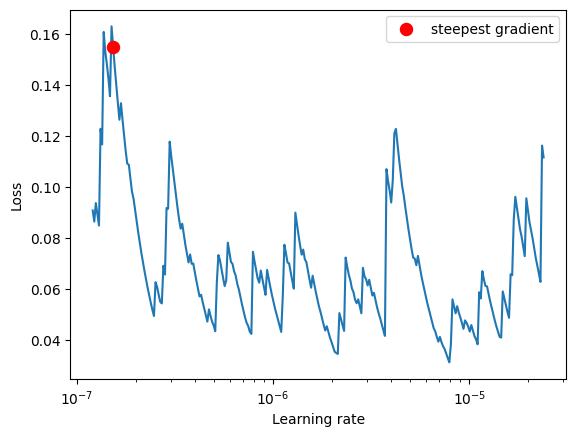

In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
from timm import create_model
from torch_lr_finder import LRFinder

# ✅ 設定設備
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ 建立 Swin Transformer 模型
model = create_model("swin_base_patch4_window12_384", pretrained=False, num_classes=len(total_classes))
model.load_state_dict(torch.load("/home/rvl/mingwei/NTUT_Deep_Learning/hw2_weight/revise_vit.pth", map_location=device))
model.to(device)

# ✅ 定義損失函數與 Optimizer（初始學習率設較低）
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-7, weight_decay=0.01)

# ✅ 建立 Learning Rate Finder
lr_finder = LRFinder(model, optimizer, criterion, device=device)

# ✅ 執行 Learning Rate Range Test
lr_finder.range_test(train_loader, end_lr=10, num_iter=1000, step_mode="exp")

# ✅ 繪製 Learning Rate vs Loss 圖
lr_finder.plot()
lr_finder.reset()



In [20]:
import warnings
import time
import torch
from PIL import Image
from tqdm import tqdm  # ✅ 引入 tqdm 來顯示進度條

torch.cuda.empty_cache()  # 清空 CUDA Cache
torch.cuda.memory_reserved(0)  # 釋放所有 GPU 記憶體

warnings.filterwarnings("ignore", category=UserWarning, module="PIL")
warnings.filterwarnings("ignore", category=UserWarning, message="Attempting to use hipBLASLt on an unsupported architecture!")


# 自定義 Logger
class EpochLogger:
    def __init__(self):
        self.history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    def log_epoch(self, epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time):
        self.history["loss"].append(train_loss)
        self.history["accuracy"].append(train_accuracy)
        self.history["val_loss"].append(val_loss)
        self.history["val_accuracy"].append(val_accuracy)

        print(f"\nEpoch {epoch + 1}:")
        print(f"  - Train Loss: {train_loss:.4f}")
        print(f"  - Train Accuracy: {train_accuracy:.4f}")
        print(f"  - Val Loss: {val_loss:.4f}")
        print(f"  - Val Accuracy: {val_accuracy:.4f}")
        print(f"  - Epoch Time: {epoch_time:.2f} seconds", flush=True)  # ✅ 確保即時輸出

# 訓練模型
num_epochs = 50
best_val_accuracy = 0.0
epoch_logger = EpochLogger()

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    start_time = time.time()

    # ✅ tqdm 進度條
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=True)
    
    for inputs, labels in train_loader_tqdm:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()  # ✅ 每個 batch 開始時清空梯度
        
        # ✅ 前向傳播
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()  # ✅ 反向傳播
        optimizer.step()  # ✅ 更新權重

        train_loss += loss.item() * inputs.size(0)  
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

        # ✅ tqdm 進度條更新
        train_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_train / total_train)

    train_loss /= total_train
    train_accuracy = correct_train / total_train
    torch.cuda.empty_cache()  # 清空 CUDA Cache
    torch.cuda.memory_reserved(0)  # 釋放所有 GPU 記憶體

    # ================= Validation =================
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        val_loader_tqdm = tqdm(val_loader, desc=f"Validation {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in val_loader_tqdm:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

            # ✅ tqdm 進度條更新
            val_loader_tqdm.set_postfix(loss=loss.item(), accuracy=correct_val / total_val)

    val_loss /= total_val
    val_accuracy = correct_val / total_val

    # ================= 記錄並更新學習率 =================
    epoch_time = time.time() - start_time
    epoch_logger.log_epoch(epoch, train_loss, train_accuracy, val_loss, val_accuracy, epoch_time)

    # ✅ 儲存最佳模型
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "hw2_weight/revise_persudo.pth")
        
    torch.cuda.empty_cache()  # 清空 CUDA Cache
    torch.cuda.memory_reserved(0)  # 釋放所有 GPU 記憶體

print(f"\n best_val_accuracy: {best_val_accuracy}")
print("\n🎉 Training Complete.")


Epoch 1/50: 100%|██████████| 2865/2865 [10:54<00:00,  4.38it/s, accuracy=0.0263, loss=4.48]
                                                                                              


Epoch 1:
  - Train Loss: 4.4417
  - Train Accuracy: 0.0263
  - Val Loss: 4.2576
  - Val Accuracy: 0.0373
  - Epoch Time: 677.74 seconds


Epoch 2/50: 100%|██████████| 2865/2865 [10:56<00:00,  4.37it/s, accuracy=0.0512, loss=4.3] 
                                                                                              


Epoch 2:
  - Train Loss: 4.1412
  - Train Accuracy: 0.0512
  - Val Loss: 4.2011
  - Val Accuracy: 0.0573
  - Epoch Time: 679.23 seconds


Epoch 3/50: 100%|██████████| 2865/2865 [10:56<00:00,  4.36it/s, accuracy=0.0859, loss=3.48]
                                                                                             

...


Epoch 45:
  - Train Loss: 0.4714
  - Train Accuracy: 0.8550
  - Val Loss: 1.0002
  - Val Accuracy: 0.7483
  - Epoch Time: 640.35 seconds


Epoch 46/50: 100%|██████████| 2865/2865 [10:19<00:00,  4.63it/s, accuracy=0.859, loss=0.829]   
                                                                                                 


Epoch 46:
  - Train Loss: 0.4611
  - Train Accuracy: 0.8593
  - Val Loss: 0.9850
  - Val Accuracy: 0.7684
  - Epoch Time: 640.44 seconds


Epoch 47/50:  85%|████████▍ | 2423/2865 [08:47<01:36,  4.59it/s, accuracy=0.862, loss=0.38]   


KeyboardInterrupt: 

In [12]:
# 載入Swin Transformer模型
model = create_model(
    'swin_base_patch4_window12_384', 
    pretrained=False,  # 不需要預訓練權重，因為會載入自己的權重
    num_classes=101
)
model = model.to(device)

# 載入訓練好的權重
model.load_state_dict(torch.load("/home/rvl/mingwei/NTUT_Deep_Learning/hw2_weight/revise_persudo.pth", map_location=device))
model.eval()  # 設置為評估模式

# 測試函數
def test_model():
    model.eval()
    all_predictions = []
    
    with torch.no_grad():
        for images, _ in tqdm(test_loader, desc="測試中"):
            images = images.to(device)
            
            # 前向傳播
            outputs = model(images)
            _, predictions = torch.max(outputs, 1)
            
            # 儲存預測結果
            all_predictions.extend(predictions.cpu().numpy())
    
    return all_predictions

# 執行測試
predictions = test_model()

# 創建索引列 (0,1,2,...,n)
indices = list(range(len(predictions)))

# 創建結果DataFrame
results_df = pd.DataFrame({
    'ID': indices,
    'Category': predictions
})

# 保存結果
results_df.to_csv('test_predictions.csv', index=False)
print(f"預測結果已保存至 test_predictions.csv")

測試中: 100%|██████████| 637/637 [00:45<00:00, 13.99it/s]

預測結果已保存至 test_predictions.csv
